In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

In [37]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [ ]:
train_images.shape

(50000, 32, 32, 3)

In [ ]:
print("Train labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Train labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


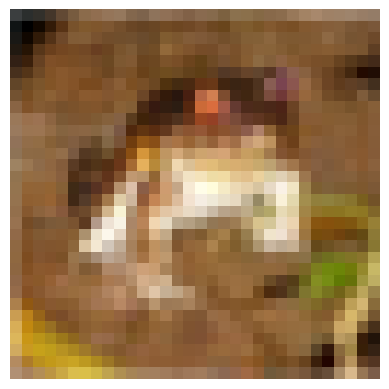

In [ ]:
plt.imshow(train_images[0])
plt.axis("off")
plt.show()

In [ ]:
print(train_labels[0])

[6]


In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

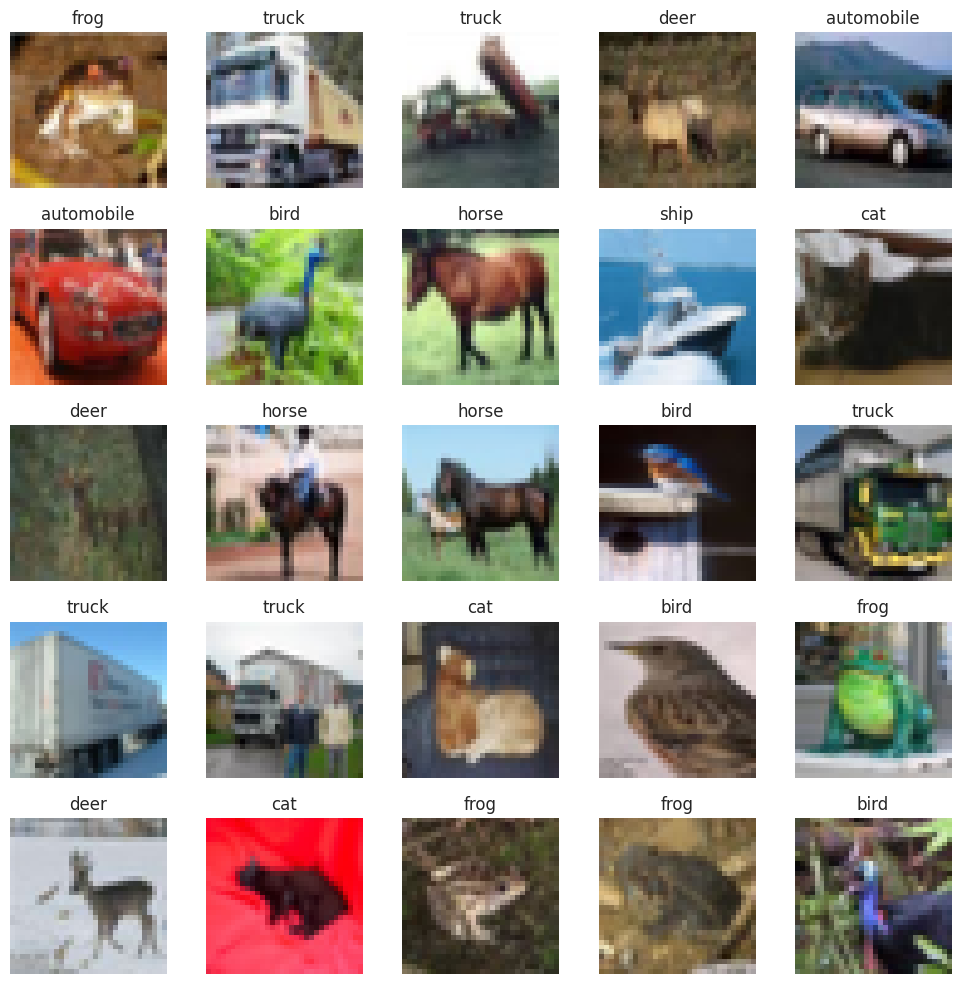

In [38]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
train_images, test_images = train_images / 255.0, test_images / 255.0

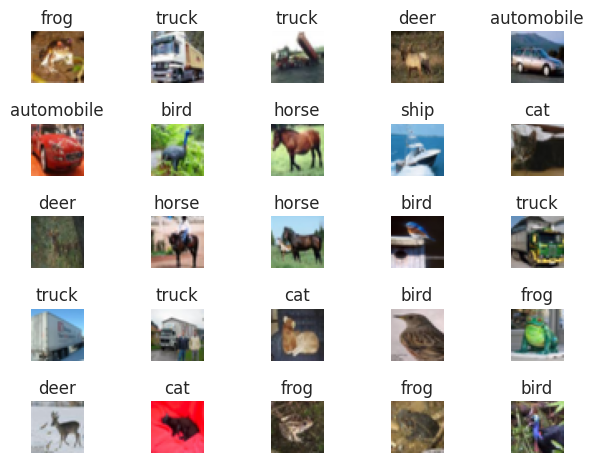

In [40]:
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
train_labels_categorical = to_categorical(train_labels)

In [52]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [46]:
#model.compile(optimizer='adam',
             # loss=tf.keras.losses.CategoricalCrossentropy(),
             # metrics=['accuracy'])

In [47]:
history = model.fit(
    train_images,
    train_labels_categorical,
    epochs=10,
    validation_split=0.1 ,
    batch_size=128)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 64s 173ms/step - accuracy: 0.1004 - loss: 9.3312 - val_accuracy: 0.0976 - val_loss: 9.6741
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.1003 - loss: 9.4925 - val_accuracy: 0.0976 - val_loss: 9.6741
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 178ms/step - accuracy: 0.1003 - loss: 9.4925 - val_accuracy: 0.0976 - val_loss: 9.6741
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 59s 167ms/step - accuracy: 0.1003 - loss: 9.4925 - val_accuracy: 0.0976 - val_loss: 9.6741
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.1003 - loss: 9.4925 - val_accuracy: 0.0976 - val_loss: 9.6741
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 174ms/step - accuracy: 0.1003 - loss: 9.4925 - val_accuracy: 0.0976 - val_loss: 9.6741
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 170ms/step - accuracy: 0.1003 - loss: 9.4925 - val_accuracy: 0.0976 - val_loss: 9.6741
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.1003 - loss: 9

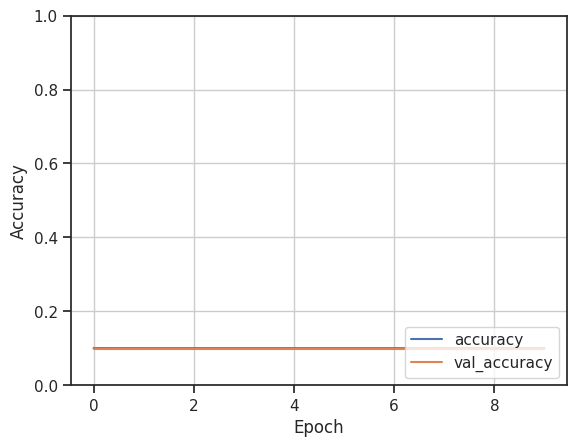

313/313 - 4s - 14ms/step - accuracy: 0.1000 - loss: 11.0570
Test accuracy: 0.10000000149011612
Test loss: 11.056998252868652


In [57]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

In [55]:
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1000 - loss: 11.0570
Test Accuracy: 0.10000000149011612


In [58]:
model = models.Sequential()

model.add(layers.Conv2D( 32, (3, 3),activation='relu',input_shape=(32, 32, 3)))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3),activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3),activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [61]:
history = model.fit(
    train_images,
    train_labels_categorical,
    epochs=20,
    batch_size=128,
    validation_split=0.1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 186ms/step - accuracy: 0.3307 - loss: 1.8005 - val_accuracy: 0.4628 - val_loss: 1.4771
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 65s 184ms/step - accuracy: 0.4878 - loss: 1.4239 - val_accuracy: 0.5666 - val_loss: 1.2235
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.5455 - loss: 1.2780 - val_accuracy: 0.5984 - val_loss: 1.1515
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 184ms/step - accuracy: 0.5863 - loss: 1.1731 - val_accuracy: 0.6380 - val_loss: 1.0271
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.6194 - loss: 1.0858 - val_accuracy: 0.6520 - val_loss: 0.9780
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.6412 - loss: 1.0218 - val_accuracy: 0.6742 - val_loss: 0.9373
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.6607 - loss: 0.9675 - val_accuracy: 0.6812 - val_loss: 0.9055
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 190ms/step - accuracy: 0.6766 - loss: 0

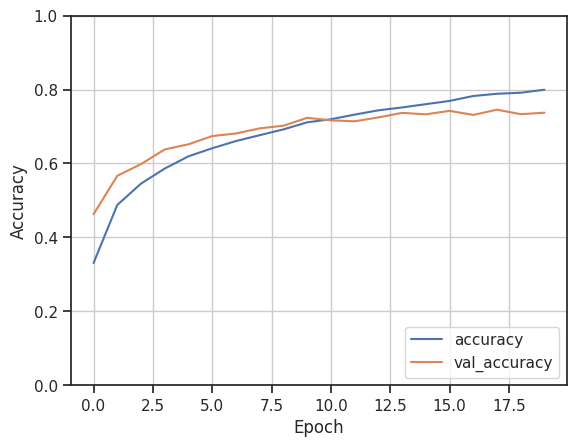

ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 1), output.shape=(None, 10)

In [62]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

In [63]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [64]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

In [65]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [67]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [68]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [69]:
history = model.fit(
    train_images,
    train_labels_categorical,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 470s 1s/step - accuracy: 0.4087 - loss: 1.7147 - val_accuracy: 0.2806 - val_loss: 2.3364 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.5328 - loss: 1.3106 - val_accuracy: 0.6212 - val_loss: 1.0802 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 469s 1s/step - accuracy: 0.5917 - loss: 1.1509 - val_accuracy: 0.6318 - val_loss: 1.0520 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 460s 1s/step - accuracy: 0.6285 - loss: 1.0577 - val_accuracy: 0.6532 - val_loss: 1.0072 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.6558 - loss: 0.9877 - val_accuracy: 0.6810 - val_loss: 0.9397 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 493s 1s/step - accuracy: 0.6771 - loss: 0.9294 - val_accuracy: 0.6858 - val_loss: 0.9181 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.6944 - loss: 0.